In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import shutil
import copy

In [2]:
# Script to standardize images in a dataset by padding and resizing

# Define the paths
original_dataset_path = '../datasets'
transformed_dataset_path = '../datasets/standardized'

# Create the new directory structure
os.makedirs(transformed_dataset_path, exist_ok=True)
categories = ['avant', 'arriere']
for category in categories:
    os.makedirs(os.path.join(transformed_dataset_path, category), exist_ok=True)

# Iterate through each category and image in the original dataset
for category in categories:
    original_category_path = os.path.join(original_dataset_path, category)
    transformed_category_path = os.path.join(transformed_dataset_path, category)

    for filename in os.listdir(original_category_path):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            # Load the original image
            original_image_path = os.path.join(original_category_path, filename)
            original_image = Image.open(original_image_path)
            if filename.endswith('.png'):
                original_image = original_image.convert('RGB')

            # Calculate the padding
            width, height = original_image.size
            if width > height:
                padding = (width - height) // 2
                pad_transform = transforms.Pad((0, padding, 0, padding), fill=0)  # Pad the top and bottom
            else:
                padding = (height - width) // 2
                pad_transform = transforms.Pad((padding, 0, padding, 0), fill=0)  # Pad the left and right

            # Define the transformation pipeline
            transform = transforms.Compose([
                pad_transform,  # Pad the image to make it square
                transforms.Resize(256)  # Resize the padded image to 256x256 pixels
            ])

            # Apply the transformation pipeline to the image
            transformed_image = transform(original_image)

            # Save the transformed image
            transformed_image_path = os.path.join(transformed_category_path, filename)
            transformed_image.save(transformed_image_path)

In [3]:
# Define the paths to the training and testing datasets
train_dataset_path = '../datasets/train'
test_dataset_path = '../datasets/test'

# Split the dataset into training and testing sets
os.makedirs(train_dataset_path, exist_ok=True)
os.makedirs(test_dataset_path, exist_ok=True)

for category in os.listdir(transformed_dataset_path):
    category_path = os.path.join(transformed_dataset_path, category)
    if os.path.isdir(category_path):
        train_category_path = os.path.join(train_dataset_path, category)
        test_category_path = os.path.join(test_dataset_path, category)
        os.makedirs(train_category_path, exist_ok=True)
        os.makedirs(test_category_path, exist_ok=True)

        for filename in os.listdir(category_path):
            if filename.endswith(('.jpg', '.jpeg', '.png')):
                image_path = os.path.join(category_path, filename)
                if np.random.random() < 0.8:  # 80% of the images will be used for training
                    shutil.copy(image_path, os.path.join(train_category_path, filename))
                else:  # 20% of the images will be used for testing
                    shutil.copy(image_path, os.path.join(test_category_path, filename))

In [4]:
# Data augmentation pipeline for files written to disk

augmentation_for_export = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),            # sens du bateau
    transforms.RandomRotation(degrees=5),              # rotation très légère, inclinaison caméra...
    transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),  # crop léger + zoom
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    transforms.Resize(256)
])

In [ ]:
# Define the number of augmented images to generate for each original image
num_augmented_images = 5

def augment_images(dataset_path):
    # Iterate through each category and image in the standardized dataset
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            for filename in os.listdir(category_path):
                if filename.endswith(('.jpg', '.jpeg', '.png')):
                    # Load the original image
                    original_image_path = os.path.join(category_path, filename)
                    original_image = Image.open(original_image_path).convert('RGB')

                    # Generate multiple augmented versions of the image
                    for i in range(num_augmented_images):
                        # Apply the data augmentation pipeline to the image
                        augmented_image = augmentation_for_export(original_image)

                        # Save the augmented image
                        augmented_image_path = os.path.join(category_path, f'augmented_{i}_{filename}')
                        augmented_image.save(augmented_image_path)

augment_images(train_dataset_path)
augment_images(test_dataset_path)

# Delete ../datasets/standardized
shutil.rmtree('../datasets/standardized')

In [6]:
# Verify and correct the image formats in the training and testing datasets

# Define the target dimensions for the images
target_size = (256, 256)

# Define the resize transformation
resize_transform = transforms.Resize(target_size)

# Function to resize images in a dataset
def resize_images(dataset_path):
    # Iterate through each category and image in the dataset
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            for filename in os.listdir(category_path):
                if filename.endswith(('.jpg', '.jpeg', '.png')):
                    # Load the image
                    image_path = os.path.join(category_path, filename)
                    image = Image.open(image_path)

                    # Resize the image
                    resized_image = resize_transform(image)

                    # Save the resized image
                    resized_image.save(image_path)

# Resize images in the train and test datasets
resize_images(train_dataset_path)
resize_images(test_dataset_path)

In [ ]:
# Load the training and testing datasets with normalization for the model
input_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = ImageFolder(train_dataset_path, transform=input_transform)
test_dataset = ImageFolder(test_dataset_path, transform=input_transform)

# Create the data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# Calculate class weights to handle class imbalance
from collections import Counter

# Initialize a counter to count the occurrences of each class
class_counts = Counter()

# Iterate through the train_loader to count the occurrences of each class
for _, labels in train_loader:
    class_counts.update(labels.tolist())

# Calculate the class weights
num_classes = len(class_counts)
class_weights = {class_idx: 1.0 / class_counts[class_idx] for class_idx in class_counts}

# Convert the class weights to a tensor
class_weights_tensor = torch.tensor([class_weights[class_idx] for class_idx in range(num_classes)], dtype=torch.float32)

In [ ]:
model = nn.Sequential(
    # Block 1
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),  
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Block 2
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Block 3
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Remplacer le Flatten massif par une moyenne globale
    # Transforme (Batch, 128, 32, 32) en (Batch, 128, 1, 1) -> (Batch, 128)
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),

    # Classifier beaucoup plus léger
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 2) 
)

In [ ]:
num_epochs = 25
lr = 0.001

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=lr)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):
    print(f'Epoch {epoch}/{num_epochs - 1}')
    print('-' * 10)

    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
        else:
            model.eval()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader if phase == 'train' else test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / (len(train_loader.dataset) if phase == 'train' else len(test_loader.dataset))
        epoch_acc = running_corrects.double() / (len(train_loader.dataset) if phase == 'train' else len(test_loader.dataset))

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_loss_history.append(epoch_loss)
            train_acc_history.append(epoch_acc)
        else:
            test_loss_history.append(epoch_loss)
            test_acc_history.append(epoch_acc)

        if phase == 'train' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            
torch.save(best_model_wts, '../models/boat_direction_model.pth')

Epoch 0/24
----------
train Loss: 0.3812 Acc: 0.8356
test Loss: 0.3705 Acc: 0.8396
Epoch 1/24
----------
train Loss: 0.2876 Acc: 0.8842
test Loss: 0.3627 Acc: 0.8277
Epoch 2/24
----------
train Loss: 0.2627 Acc: 0.8930
test Loss: 0.3205 Acc: 0.8607
Epoch 3/24
----------


KeyboardInterrupt: 

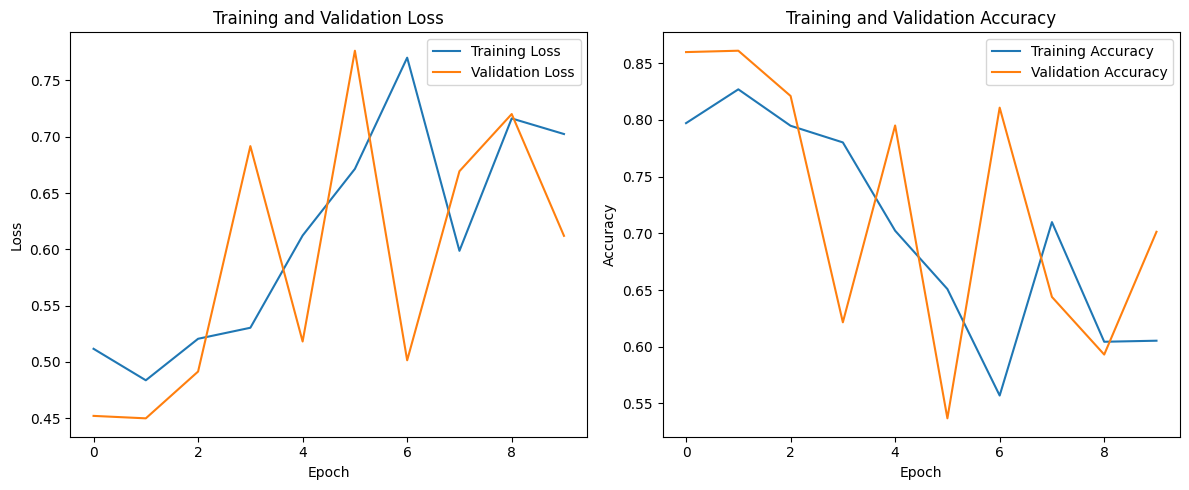

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss')
plt.plot(test_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(test_acc_history, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

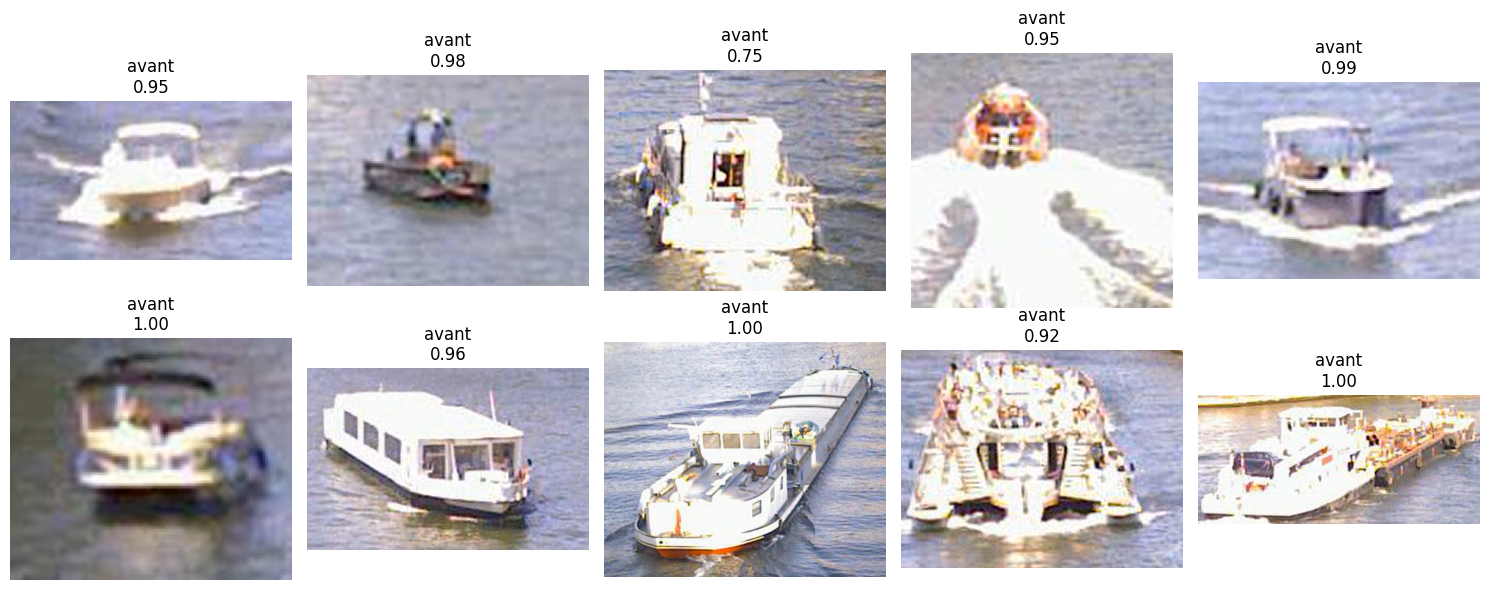

In [ ]:
import random
import torch.nn.functional as F

num_classes = 2
class_names = [
    'arriere',
    'avant',
]

model = models.resnet18(weights=None)


num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

state_dict = torch.load('../models/boat_direction_model.pth')
model.load_state_dict(state_dict)
model.eval()

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Pad(10, fill=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

validation_path = '../datasets/validation'

image_files = [
    f for f in os.listdir(validation_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

selected_images = random.sample(image_files, 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, img_name in enumerate(selected_images):
    img_path = os.path.join(validation_path, img_name)

    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        pred_prob = probs[0, pred_idx].item()

    pred_class = class_names[pred_idx]

    axes[i].imshow(img)
    axes[i].set_title(f"{pred_class}\n{pred_prob:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()